In [1]:
import numpy as np
import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.stats import loguniform
import qkeras
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt

2026-05-08 09:31:08.654758: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 09:31:08.657114: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-08 09:31:08.698267: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 09:31:08.698287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 09:31:08.699460: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
# generate test data
X_test = np.load('data/X_test.npy', allow_pickle=True)
y_test = np.load('data/y_test.npy', allow_pickle=True)

X_testzero = np.zeros((len(X_test), 100, 3))

for x in range(len(X_test)):
    for y in range(100):
        for z in range(3):
            if y >= len(X_test[x]):
                break
            X_testzero[x][y][z] = X_test[x][y][z]

# encode labels for 5 classes
num_classes = 5
y_labhot = np.zeros((len(y_test),5))

y_labhot.shape

num = 0
for x in y_test:
  if x == 0:
    y_labhot[num][0] = 1
  elif x == 1: 
    y_labhot[num][1] = 1
  elif x == 2: 
    y_labhot[num][2] = 1
  elif x == 3: 
    y_labhot[num][3] = 1
  elif x == 4: 
    y_labhot[num][4] = 1
  num = num + 1

In [3]:
model = load_model('./gru/QuickdrawEH.h5')
y_keras = model.predict(X_testzero, batch_size=512)

model.summary()

25/25 [==============================] - 3s 88ms/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100, 3)]          0         
                                                                 
 gru (GRU)                   (None, 128)               51072     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 256)               33024     
                                                                 
 activation (Activation)     (None, 256)               0         
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_

-----------------------------------
Configuration
Model
  Precision
    default:         ap_fixed<20,10>
  ReuseFactor:       64
  Strategy:          Resource
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


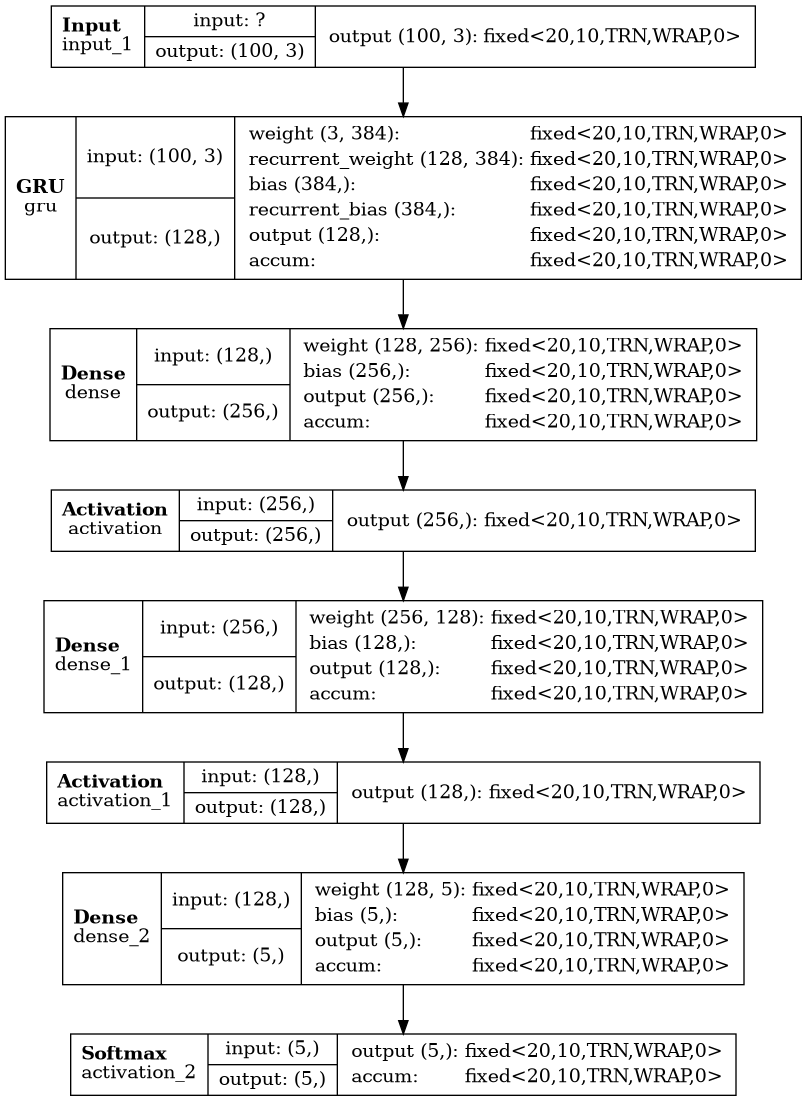

In [4]:
# create hls4ml model - edited (name)

# from EH paper:
# xcu250-figd2104-2-e
# resource strategy
# 10 int bits

import hls4ml
import plotting

# fixed<x,y> where x is total number, y is integer
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='model',
    default_precision='ap_fixed<20,10>',
    default_reuse_factor=64
)

config["Model"]["Strategy"] = "Resource"

# for layer in config['LayerName'].keys():
#     config['LayerName'][layer]['Trace'] = True

#     # softmax
#     config['LayerName']['activation_2']['implementation'] = 'argmax'

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    backend='Vivado',
    output_dir='model_1/hls4ml_gru/EH',
    part='xcu250-figd2104-2-e',
    io_type='io_stream',
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [5]:
hls_model.compile()

In [6]:
X_testzero_contig = np.ascontiguousarray(X_testzero)
y_hls = hls_model.predict(X_testzero_contig)

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()

y_pred_hls = np.argmax(y_hls, axis=1)
y_true_hls = np.argmax(y_labhot, axis=1)

print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_keras, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls, axis=1))))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_hls, y_pred_hls, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

Keras  Accuracy: 0.9452
hls4ml Accuracy: 0.93568
              precision    recall  f1-score   support

         ant       0.87      0.98      0.92      2500
         bee       0.94      0.91      0.93      2500
   butterfly       0.96      0.98      0.97      2500
    mosquito       0.92      0.82      0.87      2500
       snail       0.99      0.98      0.99      2500

    accuracy                           0.94     12500
   macro avg       0.94      0.94      0.93     12500
weighted avg       0.94      0.94      0.93     12500



In [8]:

print(y_hls)
print(y_labhot)
print(y_pred_hls)
print(y_true_hls)

print(y_hls[0])
print(np.argmax(y_hls[0]))

[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.00000000e+00 9.76562500e-04 0.00000000e+00 9.76562500e-04
  0.00000000e+00]
 [1.00000000e+00 3.02734375e-02 9.76562500e-04 1.35742188e-01
  6.83593750e-03]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 9.76562500e-04 9.76562500e-04
  1.00000000e+00]]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
[0 0 0 ... 4 4 4]
[0 0 0 ... 4 4 4]
[1. 0. 0. 0. 0.]
0


In [9]:
# name_predict, name_trace =  hls_model.trace(X_testzero)

In [10]:
# print(name_trace['rnn_densef'])
# print(name_trace['softmax'])